# Lesson 2: How Linear Regression Actually Works

## Learning Goals
- Understand what `.fit()` is doing conceptually
- Define an epoch
- Understand cost (Mean Squared Error)
- See slope (m) and intercept (b) change over time
- Recognise convergence
- Identify underfitting vs overfitting visually


## 1. What Does Training Mean?

When we run `model.fit(X, y)` the model:
1. Starts with a random line
2. Measures how wrong it is
3. Adjusts the line slightly
4. Repeats many times (epochs)

**Epoch** = one full adjustment using all training data.


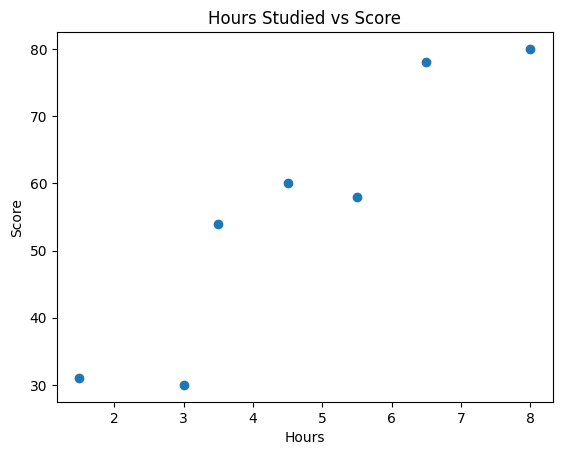

In [61]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([4.5,8.0,1.5,3.5,5.5,3.0,6.5], dtype=float)
y = np.array([60,80,31,54,58,30,78], dtype=float)

plt.scatter(X, y)
plt.title('Hours Studied vs Score')
plt.xlabel('Hours')
plt.ylabel('Score')
plt.show()

## 2. Control the Line

Equation of a line:

`y = mX + b`

- m = slope
- b = intercept


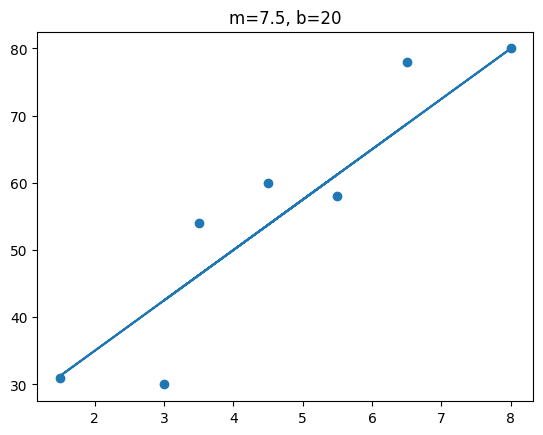

In [81]:
def plot_line(m, b):
    predictions = m*X + b
    plt.scatter(X, y)
    plt.plot(X, predictions)
    plt.title(f'm={m}, b={b}')
    plt.show()

plot_line(7.5, 20)

### Activity 1
Try different values:
- plot_line(3, 40)
- plot_line(6, 35)
- plot_line(8, 30)

Which looks best?

## 3. What Is Cost?

We measure how good the line is using Mean Squared Error (MSE).
Smaller MSE = better fit.


In [82]:
def mse(X, y, m, b):
    predictions = m*X + b
    return np.mean((y - predictions)**2)

print('MSE:', mse(X, y, 7.5, 20))

MSE: 50.223214285714285


### Activity 2
Compare MSE values for different lines.
Does the smallest MSE match the best-looking line?

## 4. Simulating Training

The model:
- Measures error
- Adjusts m and b slightly
- Repeats for many epochs


In [86]:
m = 0
b = 0
alpha = 0.01
epochs = 100

history = {'m':[], 'b':[], 'loss':[]}

for epoch in range(epochs):
    predictions = m*X + b
    error = predictions - y
    
    m -= alpha * np.mean(error * X)
    b -= alpha * np.mean(error)
    
    history['m'].append(m)
    history['b'].append(b)
    history['loss'].append(mse(X, y, m, b))

## 5. Watch Cost Decrease

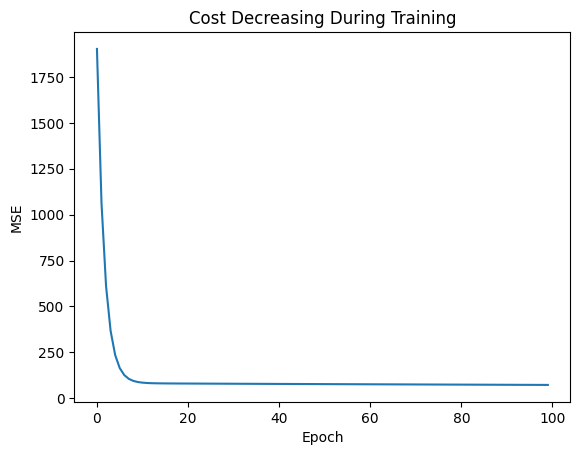

In [84]:
plt.plot(history['loss'])
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Cost Decreasing During Training')
plt.show()

## 6. Watch the Slope Change

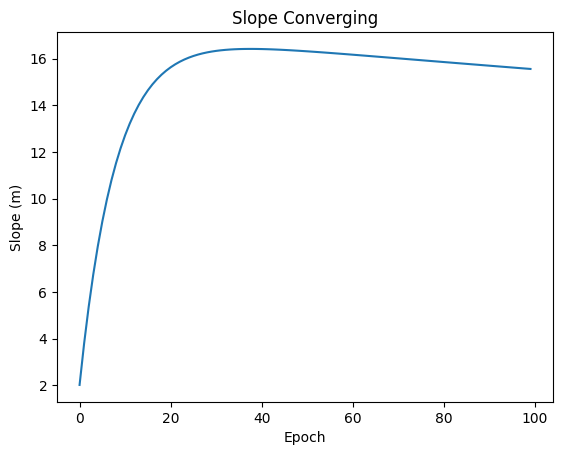

In [10]:
plt.plot(history['m'])
plt.xlabel('Epoch')
plt.ylabel('Slope (m)')
plt.title('Slope Converging')
plt.show()

## 7. See Line Improve Over Time

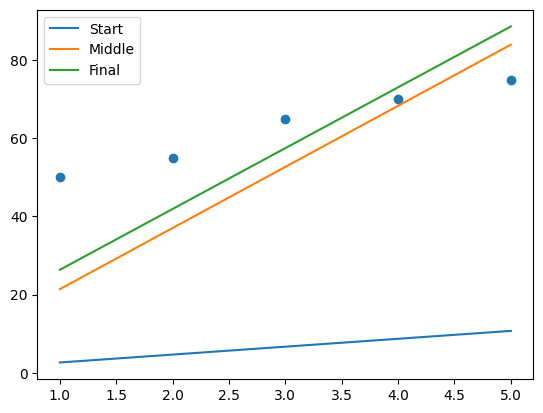

In [11]:
plt.scatter(X, y)
plt.plot(X, history['m'][0]*X + history['b'][0], label='Start')
plt.plot(X, history['m'][20]*X + history['b'][20], label='Middle')
plt.plot(X, history['m'][-1]*X + history['b'][-1], label='Final')
plt.legend()
plt.show()

## 8. Underfitting vs Overfitting

Underfitting = line too simple.
Overfitting = model too complex and fits noise.


### Activity 3
- Change alpha to 0.1
- Change alpha to 0.0001
- What happens?

Discuss why learning rate matters.